# Leçon 3: Python, calcul symbolique avec sympy.
## Calcul différentiel, intégral.



Voyons ici quelques exemples d'utilisation du calcul symbolique **sympy**, exemples tirés de phénomènes d'échanges.

Les deux exemples suivants montrent l'utilisation de **sympy** sur la distribution de Maxwell:

Tracons la distribution à 400 degrés, pour de l'argon à pression atmosphérique. n est la concentration atomique en atomes par m^3, etc...

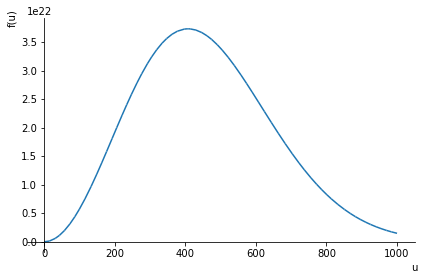

In [1]:
import sympy as sp
from IPython.display import *
%matplotlib inline
sp.init_printing(use_latex=True)
m,k,T,u = sp.symbols('m,k,T,u',positive=True)
n,f = sp.symbols('n,f')
temp=(m/(2*sp.pi*k*T))**(3/2)
f=4*sp.pi*n*u**2*temp*sp.exp(-(m*u**2/(2*k*T)))
f=f.subs([(m,40/6.023e26),(T,400),(k,1.38e-23),(n,101325/400/1.38e-23)])
sp.plot(f,(u,0,1000))

Maintenant intégrons la distribution pour obtenir la vitesse moyenne et l'énergie cinétique moyenne:
$$\large \large \frac{\int_{0}^{\infty} \frac{\sqrt{2} m^{1.5} n u^{3}}{\pi^{0.5} T^{1.5} k^{1.5} e^{\frac{m u^{2}}{2 T k}}}\, du}{\int_{0}^{\infty} \frac{\sqrt{2} m^{1.5} n u^{2}}{\pi^{0.5} T^{1.5} k^{1.5} e^{\frac{m u^{2}}{2 T k}}}\, du}$$

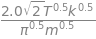

In [2]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
m,k,T,u = sp.symbols('m,k,T,u',positive=True)
n,f = sp.symbols('n,f')
temp=(m/(2*sp.pi*k*T))**(3/2)
f=4*sp.pi*n*u**2*temp*sp.exp(-(m*u**2/(2*k*T)))
U=sp.integrate(u*f,(u,0,sp.oo))/sp.integrate(f,(u,0,sp.oo))
display(U)
K=1/2*m*sp.integrate(u**2*f,(u,0,sp.oo))/sp.integrate(f,(u,0,sp.oo))
display(K)

On peut aussi voir comment on calcule obtient équation d'Hagen-Poiseuille à partir du profil de vitesse parabolique

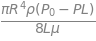

In [3]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
P0,PL,rho,mu,R,L,r= sp.symbols('P0,PL,rho,mu,R,L,r')
vz=(P0-PL)*R**2/(4*mu*L)*(1-(r/R)**2)
V=2*sp.pi*sp.integrate(vz*r,(r,0,R))/(2*sp.pi*sp.integrate(r,(r,0,R)))
Q=V*sp.pi*R**2
W=Q*rho
display(sp.simplify(W))

Et voir comment, pour un (P0-PL) donné le débit (en kg/sec) varie en fonction du rayon

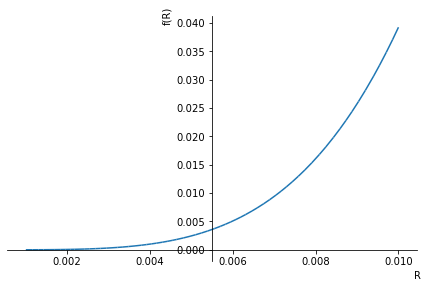

In [4]:
W=W.subs([(rho,1000),(L,100),(mu,0.001),(PL,0),(P0,1000)])
sp.plot(W,(R,0.001,0.01))

Voyons ici l'utilisation d'un dictionnaire qui remplacera avantageusement la liste dans la commande subs:

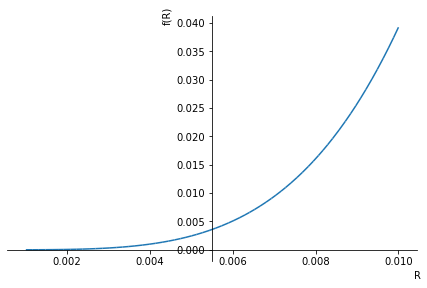

In [5]:
dico={'rho':1000,
       'L'  :1000,
       'mu' :0.001,
       'PL' :0.0,
       'P0' :1000 }
W=W.subs(dico)
sp.plot(W,(R,0.001,0.01))

On peut aussi pour le même cas d'écoulement laminaire calculer la force sur la conduite, qui est obtenue en calculant la friction à la paroi multipliée pas la surface. Autrement dit, on multiplie la composante rz du tenseur de Newton par la surface en r=R. Pour une conduite de 6 mm par exemple:

In [6]:
force=sp.diff(vz,r).subs(r,R)*2*sp.pi*R*L
display(force.subs([(rho,1000),(L,100),(mu,0.001),(PL,0),(P0,1000),(R,0.006)]))

Beaucoup plus pratique encore avec un dictionnaire, on reprend le dictionnaire précédent et on lui ajoute le rayon de la conduite:

In [7]:
force=sp.diff(vz,r).subs(r,R)*2*sp.pi*R*L
dico['R']=0.006
display(force.subs(dico))

Ces trois exemples nous ont montré des intégrales définies et des dérivées. Qu'en est-il des intégrales multiples? 

Voyons comment on calculerait le volume d'une sphère:
$$\large \int_{0}^{2 \pi}\int_{0}^{\pi}\int_{0}^{R} r^{2} \sin{\left (\theta \right )}\, dr\, d\theta\, d\phi $$


In [8]:
r,theta,phi,R=sp.symbols('r,theta,phi,R')
Volume=sp.Integral(r**2*sp.sin(theta),(r,0,R),(theta,0,sp.pi),(phi,0,2*sp.pi))
v1=sp.integrate(r**2*sp.sin(theta),(r,0,R))
v2=sp.integrate(v1,(theta,0,sp.pi))
v3=sp.integrate(v2,(phi,0,2*sp.pi))
display(v3)
# ou
v3=sp.integrate(r**2*sp.sin(theta),(r,0,R),(theta,0,sp.pi),(phi,0,2*sp.pi))


La méthode utilisée pour effectuer les intégrales multiples est plus compacte que celle utilisée, par exemple, sur Matlab.